<a href="https://colab.research.google.com/github/anjanavinoycs25-glitch/Mall-Customer-Analysis/blob/main/MALL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

In [ ]:
data = pd.read_csv("/Mall_Customers (1).csv")

In [ ]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data.tail()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [ ]:
data.shape

(200, 5)

In [ ]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data["Income Group"] = pd.cut(
    data["Annual Income (k$)"],
    bins=[0,40,70,140],
    labels=["Low","Medium","High"]
)

In [ ]:
data["Income Group"].value_counts()

,count
Income Group,
Medium,76
High,74
Low,50


In [ ]:
data.groupby("Income Group")["Spending Score (1-100)"].mean()

/tmp/ipykernel_5829/2194114019.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Income Group")["Spending Score (1-100)"].mean()


,Spending Score (1-100)
Income Group,
Low,49.480000
Medium,50.684211
High,50.189189


In [ ]:
def category(score):
    if score >= 70:
        return "High Spender"
    elif score >= 40:
        return "Medium Spender"
    else:
        return "Low Spender"

data["Customer Category"] = data["Spending Score (1-100)"].apply(category)

In [ ]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Group,Customer Category
0,1,Male,19,15,39,Low,Low Spender
1,2,Male,21,15,81,Low,High Spender
2,3,Female,20,16,6,Low,Low Spender
3,4,Female,23,16,77,Low,High Spender
4,5,Female,31,17,40,Low,Medium Spender


In [ ]:
mean_score = np.mean(data["Spending Score (1-100)"])
print(mean_score)

50.2


In [ ]:
std_score = np.std(data["Spending Score (1-100)"])
print(std_score)

25.75888196331509


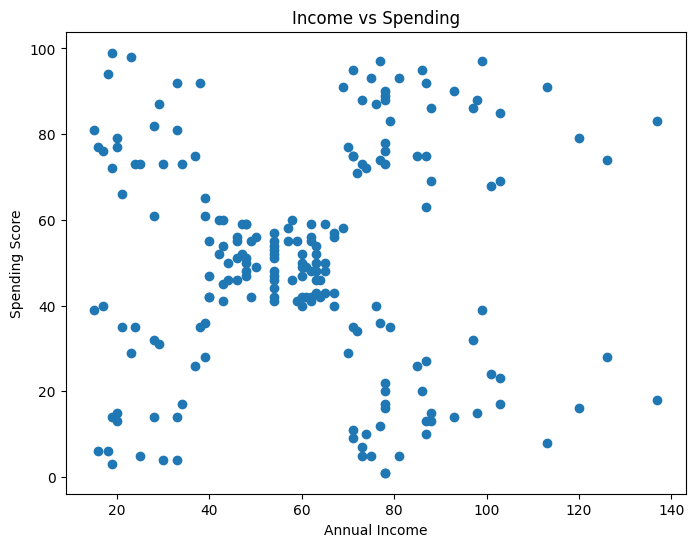

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    data["Annual Income (k$)"],
    data["Spending Score (1-100)"]
)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending")
plt.show()

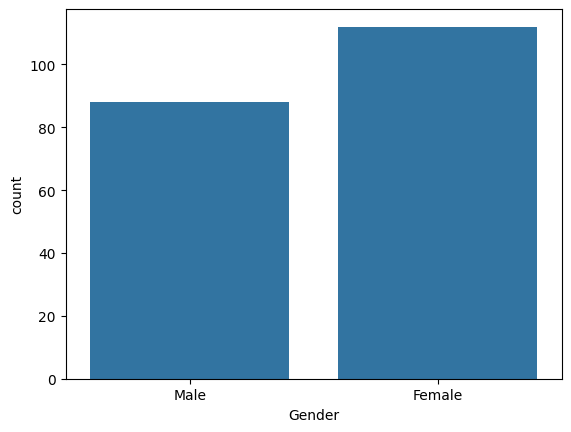

In [ ]:
sns.countplot(x="Gender", data=data)
plt.show()

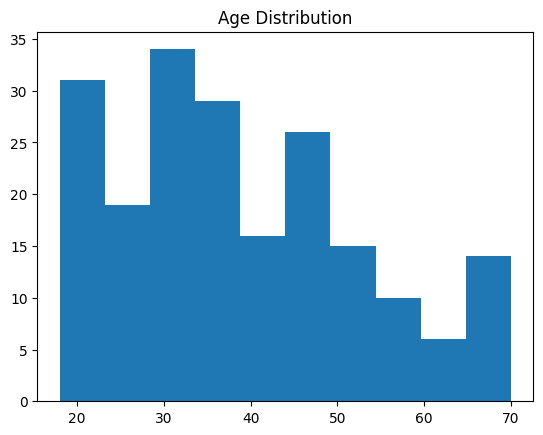

In [ ]:
plt.hist(data["Age"])
plt.title("Age Distribution")
plt.show()

In [ ]:
data.select_dtypes(include=np.number).corr()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


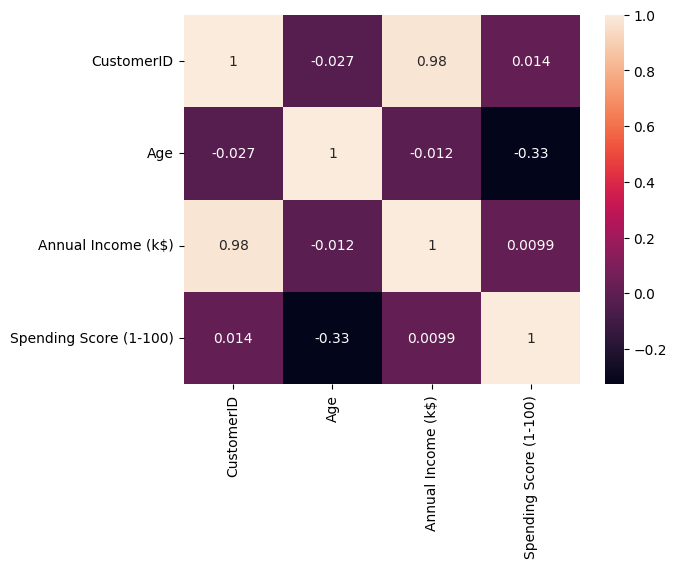

In [ ]:
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

In [ ]:
X = data[["Annual Income (k$)", "Spending Score (1-100)"]]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

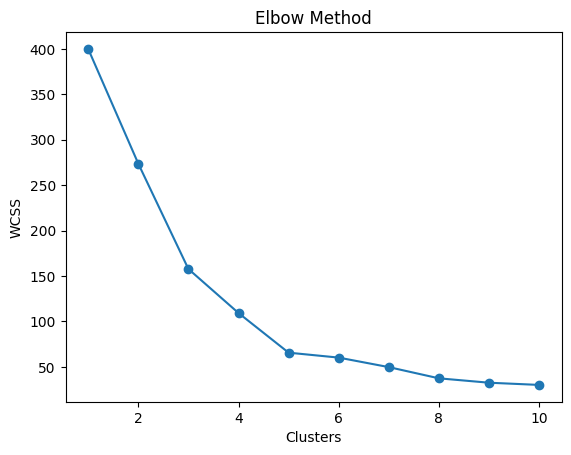

In [ ]:
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
data["Cluster"] = kmeans.fit_predict(X_scaled)

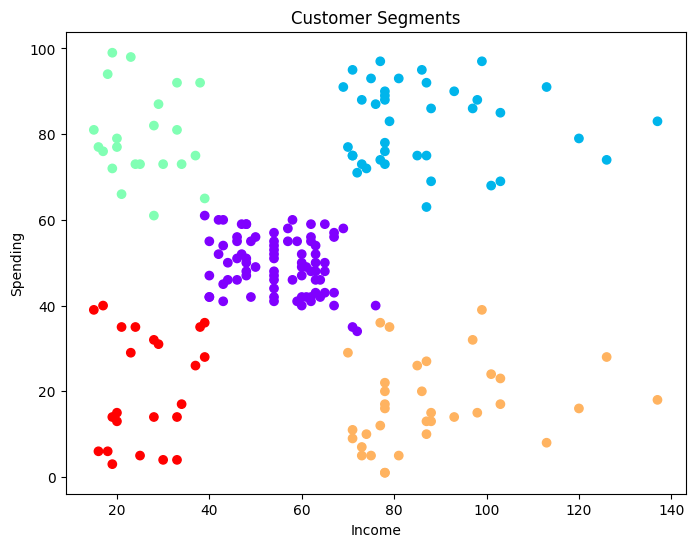

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    data["Annual Income (k$)"],
    data["Spending Score (1-100)"],
    c=data["Cluster"],
    cmap="rainbow"
)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Customer Segments")
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=5)
data["HC Cluster"] = hc.fit_predict(X_scaled)

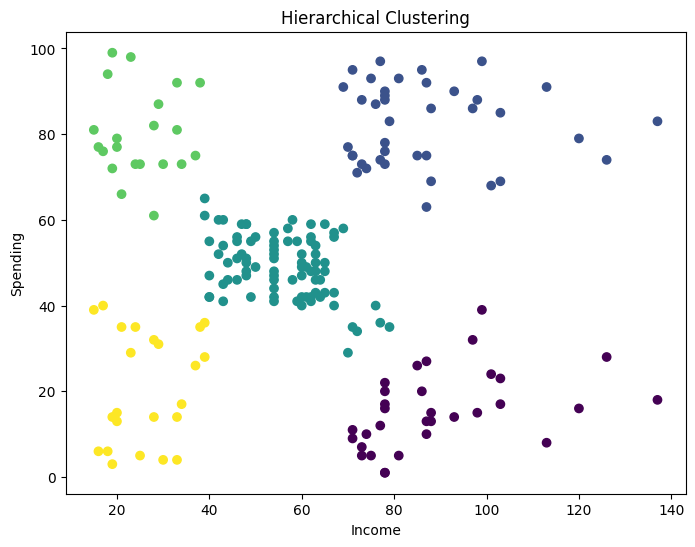

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    data["Annual Income (k$)"],
    data["Spending Score (1-100)"],
    c=data["HC Cluster"],
    cmap="viridis"
)

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Hierarchical Clustering")
plt.show()

In [ ]:
premium = data[
    (data["Annual Income (k$)"] > 70) &
    (data["Spending Score (1-100)"] > 70)
]

premium

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Group,Customer Category,Cluster,HC Cluster
127,128,Male,40,71,95,High,High Spender,1,1
129,130,Male,38,71,75,High,High Spender,1,1
131,132,Male,39,71,75,High,High Spender,1,1
133,134,Female,31,72,71,High,High Spender,1,1
135,136,Female,29,73,88,High,High Spender,1,1
137,138,Male,32,73,73,High,High Spender,1,1
139,140,Female,35,74,72,High,High Spender,1,1
141,142,Male,32,75,93,High,High Spender,1,1
143,144,Female,32,76,87,High,High Spender,1,1
145,146,Male,28,77,97,High,High Spender,1,1


In [ ]:
low = data[data["Spending Score (1-100)"] < 40]

low

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Group,Customer Category,Cluster,HC Cluster
0,1,Male,19,15,39,Low,Low Spender,4,4
2,3,Female,20,16,6,Low,Low Spender,4,4
6,7,Female,35,18,6,Low,Low Spender,4,4
8,9,Male,64,19,3,Low,Low Spender,4,4
10,11,Male,67,19,14,Low,Low Spender,4,4
12,13,Female,58,20,15,Low,Low Spender,4,4
14,15,Male,37,20,13,Low,Low Spender,4,4
16,17,Female,35,21,35,Low,Low Spender,4,4
18,19,Male,52,23,29,Low,Low Spender,4,4
20,21,Male,35,24,35,Low,Low Spender,4,4


In [ ]:
data.to_csv("/Mall_Customers (1).csv", index=False)